In [39]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import scipy.stats as sts

In [5]:
sim_matrix = np.load('multimae/ckpt/sim_matrix.npy')

In [6]:
sim_matrix.shape

(20000, 20000)

In [7]:
sim_matrix.mean()

1944176.5

In [8]:
np.histogram(sim_matrix.ravel())

(array([     1454,   1457236,  72102786, 267758912,  58527480,    146805,
             4912,       385,        27,         3]),
 array([1740407.5, 1799276.6, 1858145.8, 1917014.8, 1975883.9, 2034753. ,
        2093622.1, 2152491.2, 2211360.2, 2270229.5, 2329098.5],
       dtype=float32))

In [14]:
sim_matrix.ravel() - sim_matrix.diagonal()

SyntaxError: cannot assign to function call here. Maybe you meant '==' instead of '='? (1164962045.py, line 1)

(array([2.0000000e+00, 4.0000000e+00, 4.0000000e+00, 8.0000000e+00,
        1.0000000e+01, 2.6000000e+01, 7.4000000e+01, 1.3200000e+02,
        3.4200000e+02, 8.5200000e+02, 1.9240000e+03, 4.1800000e+03,
        8.8860000e+03, 1.7812000e+04, 3.5018000e+04, 6.7330000e+04,
        1.2514400e+05, 2.1828800e+05, 3.7039400e+05, 6.0826000e+05,
        9.7725800e+05, 1.5215000e+06, 2.2884820e+06, 3.3516240e+06,
        4.7543580e+06, 6.5735880e+06, 8.8168560e+06, 1.1485472e+07,
        1.4518576e+07, 1.7815072e+07, 2.1177660e+07, 2.4365542e+07,
        2.7172990e+07, 2.9309058e+07, 3.0599638e+07, 3.0831720e+07,
        2.9931326e+07, 2.7932966e+07, 2.4996366e+07, 2.1441646e+07,
        1.7532782e+07, 1.3632796e+07, 1.0034097e+07, 6.9681050e+06,
        4.5461680e+06, 2.7810180e+06, 1.5832280e+06, 8.4227800e+05,
        4.1559300e+05, 1.9141500e+05, 8.2557000e+04, 3.3271000e+04,
        1.3818000e+04, 6.2010000e+03, 3.2590000e+03, 2.1550000e+03,
        1.5770000e+03, 1.4610000e+03, 1.3110000e

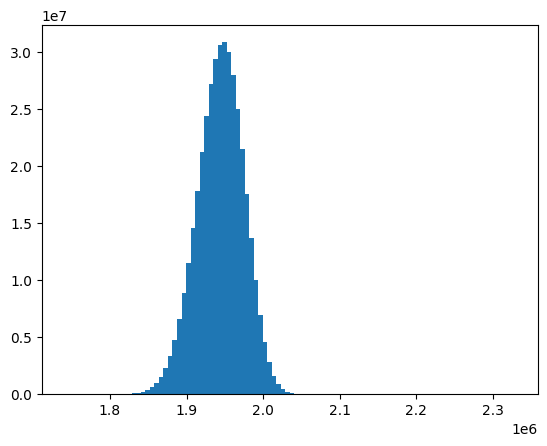

In [11]:
plt.hist(sim_matrix.ravel(), bins=100)

(array([1.000000e+00, 0.000000e+00, 2.000000e+00, 1.000000e+00,
        2.000000e+00, 3.000000e+00, 3.000000e+00, 2.000000e+00,
        3.000000e+00, 2.200000e+01, 2.600000e+01, 3.400000e+01,
        6.600000e+01, 1.200000e+02, 2.340000e+02, 3.580000e+02,
        6.260000e+02, 1.042000e+03, 1.735000e+03, 2.674000e+03,
        4.282000e+03, 6.700000e+03, 1.010500e+04, 1.588900e+04,
        2.346200e+04, 3.557600e+04, 5.071700e+04, 7.220600e+04,
        1.016620e+05, 1.406150e+05, 1.928750e+05, 2.628910e+05,
        3.521460e+05, 4.671350e+05, 6.092530e+05, 7.856060e+05,
        1.003223e+06, 1.263459e+06, 1.573632e+06, 1.940054e+06,
        2.357106e+06, 2.835791e+06, 3.369263e+06, 3.949424e+06,
        4.581714e+06, 5.251560e+06, 5.927211e+06, 6.621572e+06,
        7.292719e+06, 7.924676e+06, 8.505401e+06, 9.009768e+06,
        9.405024e+06, 9.694055e+06, 9.852777e+06, 9.865786e+06,
        9.729693e+06, 9.443998e+06, 9.023022e+06, 8.460670e+06,
        7.810670e+06, 7.082111e+06, 6.29

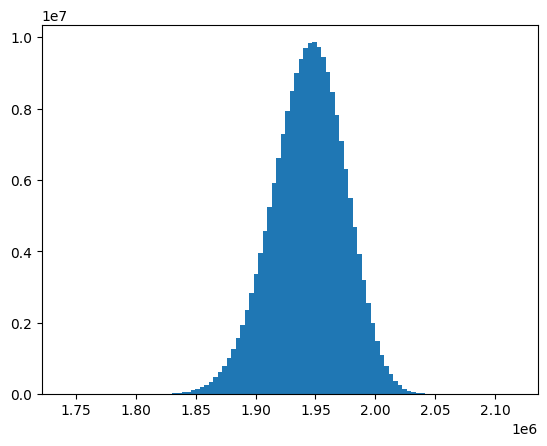

In [15]:
def upper_tri_masking(A):
    m = A.shape[0]
    r = np.arange(m)
    mask = r[:,None] < r
    return A[mask]

plt.hist(upper_tri_masking(sim_matrix).ravel(), bins=100)

(array([2.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 4.000e+00, 0.000e+00, 6.000e+00, 2.000e+00, 8.000e+00,
        1.000e+01, 7.000e+00, 1.200e+01, 1.700e+01, 1.000e+01, 1.900e+01,
        1.500e+01, 2.600e+01, 2.100e+01, 4.100e+01, 4.900e+01, 6.200e+01,
        7.100e+01, 7.000e+01, 7.600e+01, 1.020e+02, 9.000e+01, 1.290e+02,
        1.400e+02, 1.450e+02, 1.860e+02, 2.190e+02, 2.410e+02, 2.650e+02,
        2.830e+02, 3.540e+02, 3.640e+02, 4.000e+02, 4.270e+02, 4.610e+02,
        5.320e+02, 6.100e+02, 6.760e+02, 6.510e+02, 7.630e+02, 8.330e+02,
        8.400e+02, 9.440e+02, 9.720e+02, 1.005e+03, 1.034e+03, 1.010e+03,
        9.570e+02, 8.470e+02, 7.650e+02, 6.860e+02, 5.760e+02, 5.110e+02,
        3.940e+02, 3.290e+02, 2.160e+02, 1.610e+02, 1.300e+02, 8.300e+01,
        5.200e+01, 3.700e+01, 2.400e+01, 9.000e+00, 8.000e+00, 0.000e+00,
        3.000e+00, 0.000e+00, 3.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

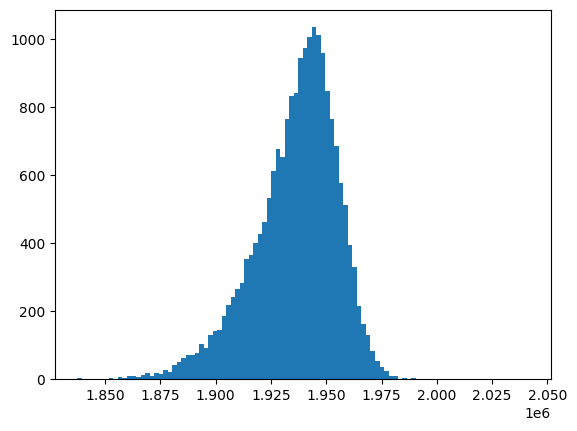

In [38]:
plt.hist(sim_matrix[5], bins=100)

In [ ]:
not_normal = []
for i in tqdm(range(20000)):
    cur_test = sts.normaltest(sim_matrix[i]).pvalue
    if cur_test > 0.05:
        not_normal.append(i)

In [19]:
np.argmin(sim_matrix[0])

9470

In [21]:
task_path = '/home/data/dq/clevr_complex/train/rgb/'
files = sorted(os.listdir(task_path))

In [22]:
files[0]

'0_0.png'

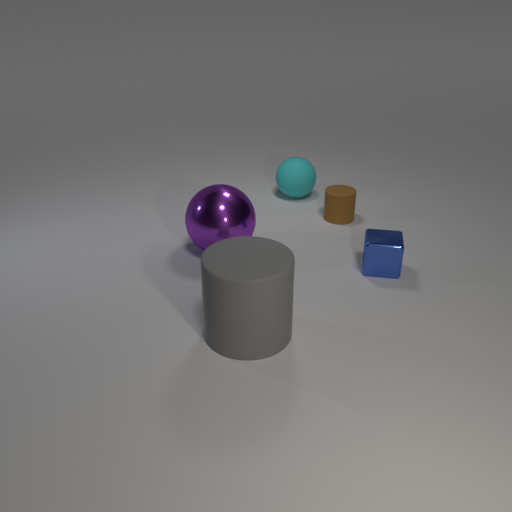

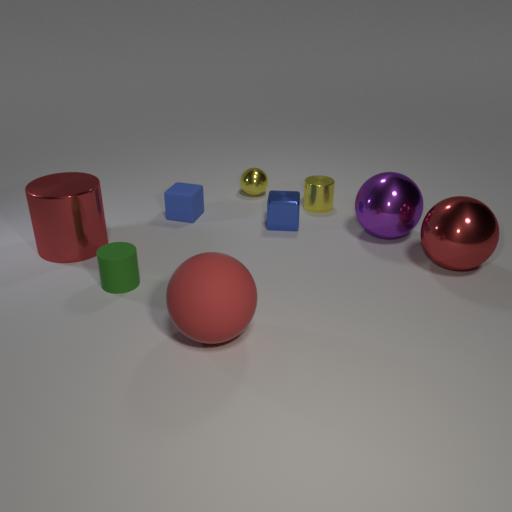

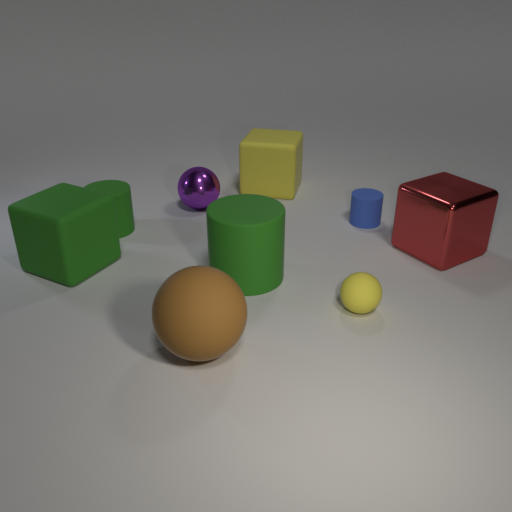

In [33]:
img = Image.open(task_path + files[0]).convert('RGB')
display(img)

img = Image.open(task_path + files[np.argmin(sim_matrix[0])]).convert('RGB')
display(img)

idx = np.argpartition(sim_matrix[0], 2)
img = Image.open(task_path + files[idx[1]]).convert('RGB')
display(img)

In [32]:
idx

array([ 9470,  8276, 11637, ..., 19997, 19998, 19999])

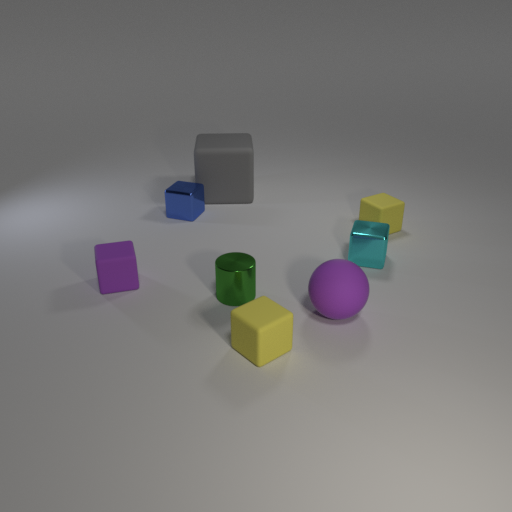

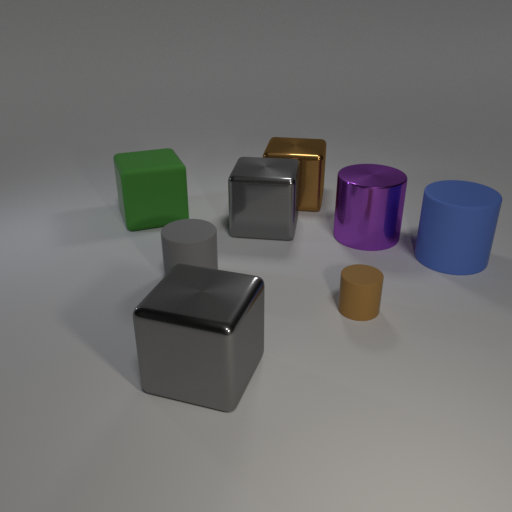

In [27]:
img = Image.open(task_path + files[1]).convert('RGB')
display(img)

img = Image.open(task_path + files[np.argmin(sim_matrix[1])]).convert('RGB')
display(img)